In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

In [3]:
df = pd.read_excel("datasets/titanic.xls")
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [4]:
df.shape

(1309, 14)

In [5]:
df.columns

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [7]:
df.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


## Cleaning

In [8]:
df.drop(['fare', 'home.dest', 'name'], axis=1, inplace=True)

In [9]:
df

,pclass,survived,sex,age,sibsp,parch,ticket,cabin,embarked,boat,body
0,1,1,female,29.0000,0,0,24160,B5,S,2,NaN
1,1,1,male,0.9167,1,2,113781,C22 C26,S,11,NaN
2,1,0,female,2.0000,1,2,113781,C22 C26,S,NaN,NaN
3,1,0,male,30.0000,1,2,113781,C22 C26,S,NaN,135.0
4,1,0,female,25.0000,1,2,113781,C22 C26,S,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,female,14.5000,1,0,2665,NaN,C,NaN,328.0
1305,3,0,female,NaN,1,0,2665,NaN,C,NaN,NaN
1306,3,0,male,26.5000,0,0,2656,NaN,C,NaN,304.0
1307,3,0,male,27.0000,0,0,2670,NaN,C,NaN,NaN


In [10]:
df['age'] = df['age'].fillna(0)

## Histogram

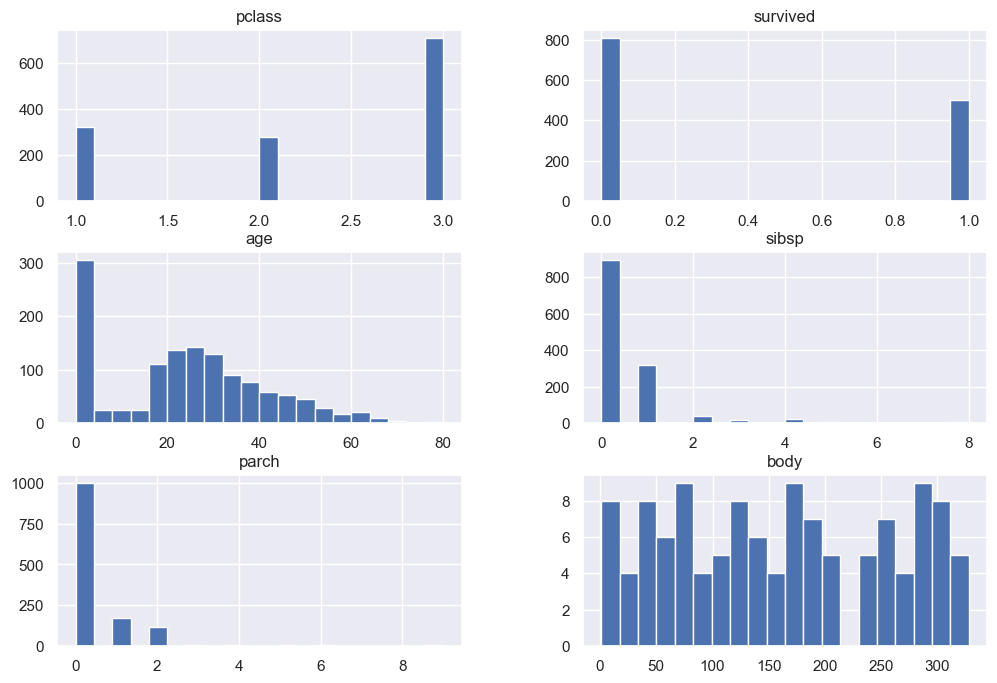

In [16]:
df.hist(bins=20,figsize=(12,8))
plt.show()

## Outliers

In [17]:
df_copy = df.copy()

In [18]:
df_copy['age'].iloc[0:10] = 500

C:\Users\qtagz\AppData\Local\Temp\ipykernel_29476\4200277411.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_copy['age'].iloc[0:10] = 500
C:\Users\qtagz\AppData\Local\Temp\ipykernel_29476\4200277411.py:1: SettingWithCopyWarning: 
A va

In [19]:
df_copy.head(15)

,pclass,survived,sex,age,sibsp,parch,ticket,cabin,embarked,boat,body
0,1,1,female,500.0,0,0,24160,B5,S,2,NaN
1,1,1,male,500.0,1,2,113781,C22 C26,S,11,NaN
2,1,0,female,500.0,1,2,113781,C22 C26,S,NaN,NaN
3,1,0,male,500.0,1,2,113781,C22 C26,S,NaN,135.0
4,1,0,female,500.0,1,2,113781,C22 C26,S,NaN,NaN
5,1,1,male,500.0,0,0,19952,E12,S,3,NaN
6,1,1,female,500.0,1,0,13502,D7,S,10,NaN
7,1,0,male,500.0,0,0,112050,A36,S,NaN,NaN
8,1,1,female,500.0,2,0,11769,C101,S,D,NaN
9,1,0,male,500.0,0,0,PC 17609,NaN,C,NaN,22.0


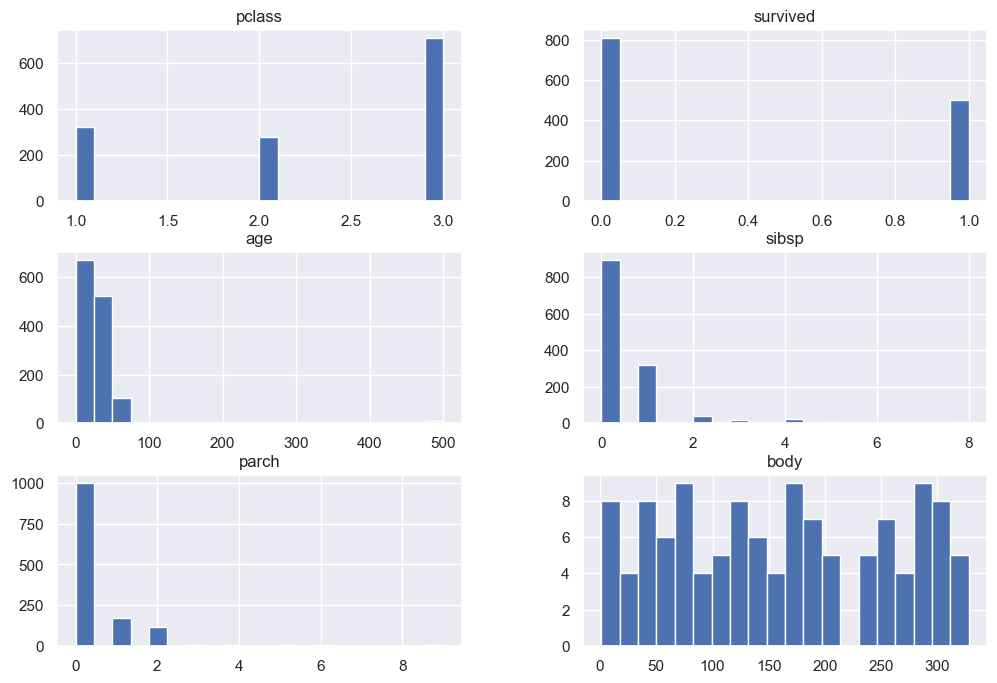

In [20]:
df_copy.hist(bins=20,figsize=(12,8))
plt.show()

In [21]:
df_copy[df_copy['age'] > 100]['age'].index

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='int64')

In [23]:
df_copy.iloc[5]

pclass          1
survived        1
sex          male
age         500.0
sibsp           0
parch           0
ticket      19952
cabin         E12
embarked        S
boat            3
body          NaN
Name: 5, dtype: object

In [24]:
df_copy.drop(df_copy[df_copy['age'] > 100]['age'].index, inplace=True)

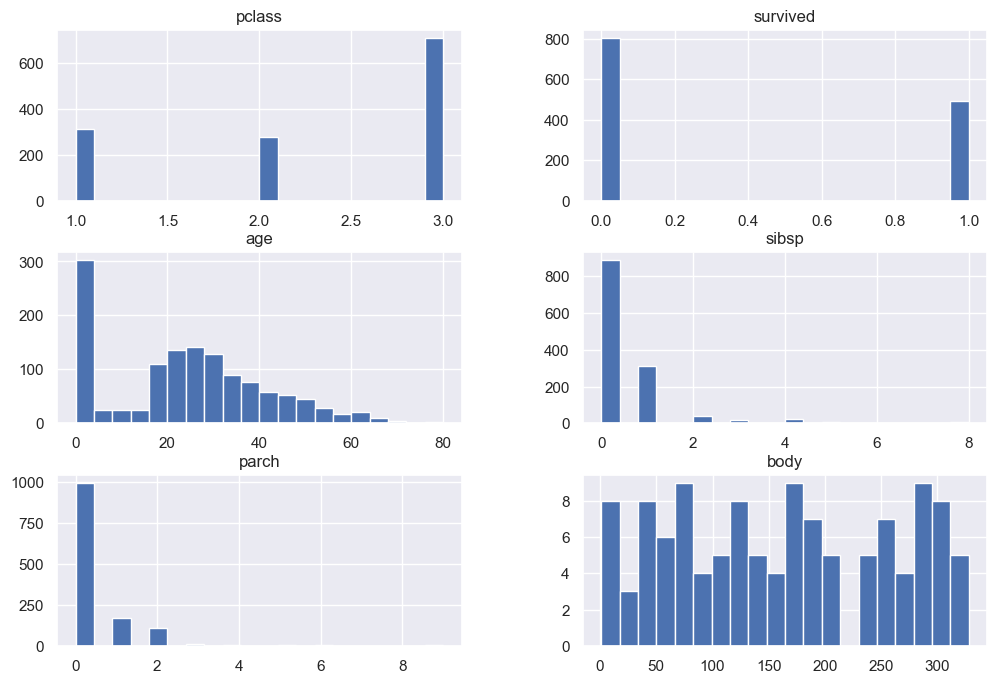

In [25]:
df_copy.hist(bins=20,figsize=(12,8))
plt.show()

In [26]:
df_copy.shape

(1299, 11)

### I'm Alive

In [27]:
df['sex'].value_counts()

sex
male      843
female    466
Name: count, dtype: int64

In [28]:
df['pclass'].value_counts()

pclass
3    709
1    323
2    277
Name: count, dtype: int64

In [29]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [31]:
gender_df = df[df['sex'] == 'male']
survived = gender_df[gender_df['survived'] == 1]
survived.shape[0]

161

In [32]:
survived_percentage = (survived.shape[0] / gender_df.shape[0]) * 100
survived_percentage

19.098457888493474

In [35]:
for gen in df['sex'].unique():
    print(gen)
    gender_df = df[df['sex'] == gen]
    survived = gender_df[gender_df['survived'] == 1]
    survived_percentage = (survived.shape[0] / gender_df.shape[0]) * 100
    print("Count: ", gender_df.shape[0])
    print(f"Survived percentage for {gen} is {survived_percentage:.2f}%")
    print("\n==========\n")

female
Count:  466
Survived percentage for female is 72.75%


male
Count:  843
Survived percentage for male is 19.10%




In [37]:
for x_class in df['pclass'].unique():
    print(x_class)

    x_df = df[df['pclass']==x_class]
    survived = x_df[x_df['survived'] == 1]
    survived_percentage = (survived.shape[0] / x_df.shape[0]) * 100
    print("Count: ", x_df.shape[0])
    print(f"Survived percentage for {x_class} is {survived_percentage:.2f}%")
    print("\n==========\n")


1
Count:  323
Survived percentage for 1 is 61.92%


2
Count:  277
Survived percentage for 2 is 42.96%


3
Count:  709
Survived percentage for 3 is 25.53%




In [38]:
def age_to_category(age):
    if age < 4:
        return 0 #baby
    elif age < 10:
        return 1 #child
    elif age < 21:
        return 2 #"teen"
    elif age < 33:
        return 3 #young adult
    elif age < 50:
        return 4 #adult
    return 5 #"elder"

age_cats = {
    0: "baby",
    1: "child",
    2: "teen",
    3: "young adult",
    4: "adult",
    5: "elder"
}

In [40]:
df['age_phase'] = df['age']

In [41]:
for i in range(df.shape[0]):
    df['age_phase'].iloc[i] = age_to_category(df['age'].iloc[i])
    

C:\Users\qtagz\AppData\Local\Temp\ipykernel_29476\3553563254.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['age_phase'].iloc[i] = age_to_category(df['age'].iloc[i])
C:\Users\qtagz\AppData\Local\Temp\ipykernel_29476\3553563254.py:2: 

In [42]:
df.head()

,pclass,survived,sex,age,sibsp,parch,ticket,cabin,embarked,boat,body,age_phase
0,1,1,female,29.0000,0,0,24160,B5,S,2,NaN,3.0
1,1,1,male,0.9167,1,2,113781,C22 C26,S,11,NaN,0.0
2,1,0,female,2.0000,1,2,113781,C22 C26,S,NaN,NaN,0.0
3,1,0,male,30.0000,1,2,113781,C22 C26,S,NaN,135.0,3.0
4,1,0,female,25.0000,1,2,113781,C22 C26,S,NaN,NaN,3.0


<Axes: >

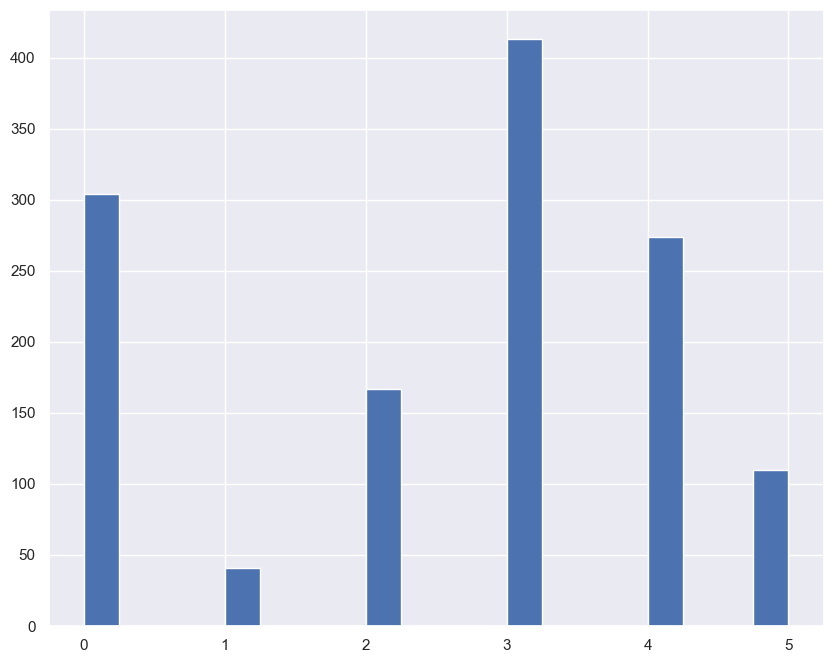

In [44]:
df['age_phase'].hist(bins=20, figsize=(10,8))